#### 한국어 텍스트 분석
- 네이버 영화리뷰

In [1]:
# 한국어 형태소분석기 설치 (설치 완료 후 세션 재실행 필요할 수 있음)

#!pip install konlpy
#!pip install JPype1
#!apt-get install -y openjdk-11-jdk

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings("ignore")

# Google Drive 연결, 작업공간 설정
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/deeplearning_study')

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow import keras

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# data loading : tab으로 구분된 텍스트파일
train = pd.read_csv('naver_train.txt', sep='\t')
test = pd.read_csv('naver_train.txt', sep='\t')
#train = pd.read_table('naver_train.txt')
#test = pd.read_table('naver_test.txt')

train = train.dropna()
test = test.dropna()

print(train.shape, test.shape)
display(train.head())

(149995, 3) (149995, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [4]:
#train['label'].value_counts()
test['label'].value_counts()

,count
label,
0,75170
1,74825


평균리뷰길이: 35.204526817560584
최소리뷰길이: 1
최대리뷰길이: 146


<Axes: xlabel='document', ylabel='Count'>

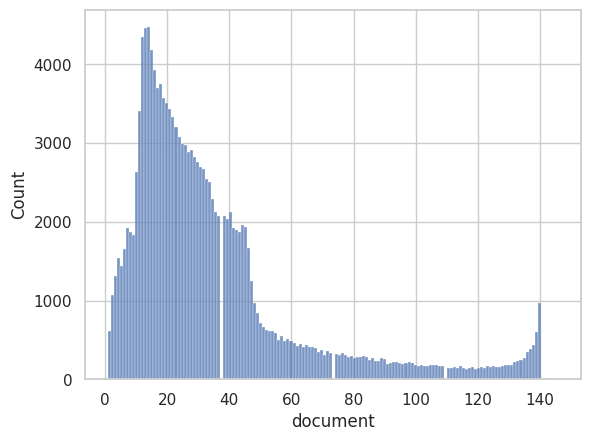

In [5]:
review_length = train['document'].str.len()

print('평균리뷰길이:', np.mean(review_length))
print('최소리뷰길이:', np.min(review_length))
print('최대리뷰길이:', np.max(review_length))

sns.histplot(review_length)

In [6]:
# 형태소 분리
from konlpy.tag import Okt
okt = Okt()

####################################################################################
# 시간 단축을 위해 데이터 일부만 사용
train = train.sample(20000, random_state=42)
test = test.sample(5000, random_state=42)
####################################################################################

def tokenize(text):
    return okt.morphs(text)

train['tokens'] = train['document'].apply(tokenize)
test['tokens'] = test['document'].apply(tokenize)

In [7]:
# 토큰화 결과 확인
k = 2
print("원문:", train['document'].iloc[k])
print("토큰:", train['tokens'].iloc[k])

원문: 굉장히 저평가되는 영화중 하나라고 생각함
토큰: ['굉장히', '저', '평가', '되는', '영화', '중', '하나', '라고', '생각', '함']


In [8]:
# token -> encoding
tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(train['tokens'])

X_train = tokenizer.texts_to_sequences(train['tokens'])
X_test = tokenizer.texts_to_sequences(test['tokens'])

y_train = train['label'].values
y_test = test['label'].values

# padding
maxlen = 300
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

In [9]:
# GRU model
model = keras.Sequential()
model.add(keras.layers.Embedding(20000, 64, input_length=maxlen))
model.add(
    keras.layers.GRU(
        16,
        dropout=0.3,
        recurrent_dropout=0.3
    )
)
model.add(keras.layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model_gru_naver.keras',
    monitor='val_loss',
    save_best_only=True
)

# train
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 165s 632ms/step - accuracy: 0.7154 - loss: 0.5479 - val_accuracy: 0.8030 - val_loss: 0.4265
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 195s 623ms/step - accuracy: 0.8601 - loss: 0.3318 - val_accuracy: 0.8152 - val_loss: 0.4005
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 156s 626ms/step - accuracy: 0.9120 - loss: 0.2269 - val_accuracy: 0.8095 - val_loss: 0.4444
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 154s 617ms/step - accuracy: 0.9407 - loss: 0.1628 - val_accuracy: 0.8083 - val_loss: 0.4899
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 154s 616ms/step - accuracy: 0.9567 - loss: 0.1246 - val_accuracy: 0.8052 - val_loss: 0.5613
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 203s 620ms/step - accuracy: 0.9642 - loss: 0.1022 - val_accuracy: 0.7990 - val_loss: 0.5974
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 202s 618ms/step - accuracy: 0.9709 - loss: 0.0840 - val_accuracy: 0.8005 - val_loss: 0.6729


,accuracy,loss,val_accuracy,val_loss
2,0.912000,0.226911,0.80950,0.444388
3,0.940687,0.162802,0.80825,0.489897
4,0.956688,0.124568,0.80525,0.561310
5,0.964188,0.102225,0.79900,0.597417
6,0.970937,0.084046,0.80050,0.672916


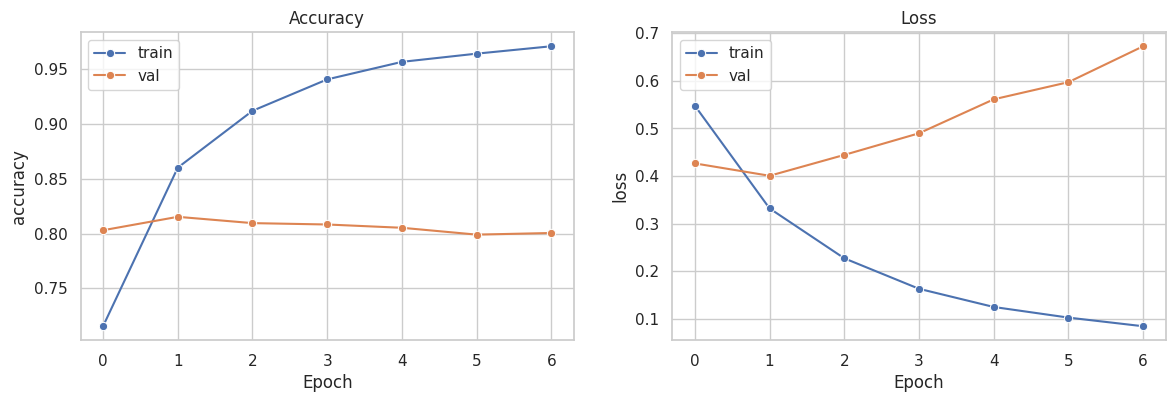

In [11]:
# visuzlaize
df_history = pd.DataFrame(history.history)
display(df_history.tail())

fig, axes = plt.subplots(1,2, figsize=(14,4))

sns.lineplot(data=df_history, x=df_history.index, y='accuracy', marker='o', label='train', ax=axes[0])
sns.lineplot(data=df_history, x=df_history.index, y='val_accuracy', marker='o', label='val', ax=axes[0])
axes[0].set_title('Accuracy')
axes[0].set_xlabel("Epoch")
axes[0].legend()

sns.lineplot(data=df_history, x=df_history.index, y='loss', marker='o', label='train', ax=axes[1])
sns.lineplot(data=df_history, x=df_history.index, y='val_loss', marker='o', label='val', ax=axes[1])
axes[1].set_title('Loss')
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.show()

In [12]:
# test
model.evaluate(X_test, y_test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 200ms/step - accuracy: 0.9454 - loss: 0.1818


[0.18180546164512634, 0.9453999996185303]

---
####[참고] 가상의 리뷰를 입력하고, 모델로 긍정/부정 판별해보기

In [13]:
# best모델을 사용한 함수 정의
from tensorflow.keras.models import load_model
best_model = load_model('best_model_gru_naver.keras')

def predict_sentiment(sentence):
    tokens = okt.morphs(sentence)
    seq = tokenizer.texts_to_sequences([tokens])
    padded = pad_sequences(seq, maxlen=maxlen)

    score = best_model.predict(padded)[0][0]
    if score > 0.5:
        print("😊 긍정 리뷰입니다.")
    else:
        print("😡 부정 리뷰입니다.")

    print("예측 확률:", round(score,4))

In [14]:
# 임의의 리뷰 텍스트 입력
my_review = "1~3편과 똑같은 스토리지만, 역시 컴퓨터 그래픽과 스케일은 대단하다"
predict_sentiment(my_review)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
😊 긍정 리뷰입니다.
예측 확률: 0.6973
